In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np
import re
from collections import Counter
import nltk
from nrclex import NRCLex
import plotly.graph_objects as go

# Download stopwords if not already done
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jitu1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [38]:
#Loading Clinical Dataset : Reads a CSV file into a pandas DataFrame and displays the first 5 rows.

data = pd.read_csv(r'D:\MSAI_Coursework\Summer2025\High_risk_project\ppd_dataset_clinical_stories.csv')
df = pd.DataFrame(data)
df.head(5)

,post_text,risk_label,trajectory
0,I feel strong knowing that I’m doing everythin...,0,stable_pos
1,6 months postpartum from a C-section. Pre preg...,1,neg_to_pos
2,I feel like stranger to my baby and my only jo...,1,stable_neg
3,Gosh the hardest part I’ve felt has been seein...,1,stable_neg
4,I felt so alone during the first few weeks aft...,1,stable_neg


In [ ]:
# Extracting Emotion Trajectory from Text : Splits text into sentences and assigns each a dominant emotion using NRCLex.

# Function to preprocess text: tokenize sentences and get dominant emotion per sentence
def extract_emotion_trajectory(text):
    # Tokenize into sentences
    sentences = nltk.sent_tokenize(text)
    emotions = []
    for sentence in sentences:
        # Use NRCLex to get emotion scores for the sentence
        emotion_obj = NRCLex(sentence)
        # Extract emotions with their scores
        emotion_scores = emotion_obj.raw_emotion_scores
        if emotion_scores:
            # Pick the emotion with the highest count as dominant
            dominant_emotion = max(emotion_scores, key=emotion_scores.get)
        else:
            dominant_emotion = 'neutral'
        emotions.append(dominant_emotion)
    return emotions

In [40]:
# Applying Emotion Detection to Posts : Applies emotion extraction to each post and prints the original text with its sentence-wise emotion trajectory.
df['emotion_trajectory'] = df['post_text'].apply(extract_emotion_trajectory)

# Show the result
for idx, row in df.iterrows():
    print(f"Post {idx+1}:")
    print(f"Text: {row['post_text']}")
    print(f"Detected Emotions: {row['emotion_trajectory']}")
    print("-----")

Post 1:
Text: I feel strong knowing that I’m doing everything I can for my baby, and that includes taking care of myself. Self-love is part of motherhood too, and I make sure to give myself grace. Taking walks, reading, or catching up with friends refreshes my spirit and allows me to give my best to my family.
Detected Emotions: ['positive', 'positive', 'positive']
-----
Post 2:
Text: 6 months postpartum from a C-section. Pre pregnancy- 130 lbs Pregnant- 172 lbs Postpartum- 155 lbs.
Pre pregnancy I had a flat stomach, no stretch marks, and an innie belly button. At my 6 week postpartum visit my doctor even said, "Wow, pregnancy really wrecked your body."
Currently combo feeding, and my body is storing fat while breastfeeding. I feel so insecure that I look so pregnant.
I know I have diastasis recti, and I do small YouTube workouts to help heal it, and go on walks almost daily. Now that my baby is bigger, I'm going to really crack down and get serious about consistently working out.
Is 

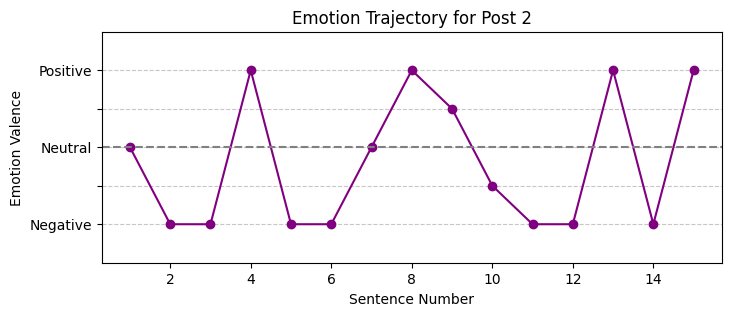

In [43]:
#Visualizing Emotion Trajectory of a Post : Converts sentence-level emotions of a post into sentiment scores and plots them to show emotional flow.

# Map NRC emotions to sentiment polarity for visualization
emotion_to_val = {
    'joy': 2,
    'positive': 2,
    'trust': 1,
    'anticipation': 1,
    'fear': -1,
    'sadness': -2,
    'anger': -2,
    'disgust': -2,
    'surprise': 0,
    'neutral': 0
}

# Get first post's emotions
emotions = df.loc[1, 'emotion_trajectory']

# Map emotions to values for plotting
y_vals = [emotion_to_val.get(e, 0) for e in emotions]

# Plot emotion trajectory
plt.figure(figsize=(8, 3))
plt.plot(range(1, len(y_vals)+1), y_vals, marker='o', linestyle='-', color='purple')
plt.title('Emotion Trajectory for Post 2')
plt.xlabel('Sentence Number')
plt.ylabel('Emotion Valence')
plt.ylim(-3, 3)
plt.axhline(0, color='grey', linestyle='--')
plt.yticks([-2, -1, 0, 1, 2], ['Negative', '', 'Neutral', '', 'Positive'])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

# Compare Automated Emotion Trajectories with Manual Trajectory Labels

In [44]:
#Classifying and Evaluating Emotion Arcs : Maps sentence emotions to sentiment valence, classifies each post's emotional arc type, and compares with ground truth using a confusion matrix and classification report.

# Map emotion polarity for each basic NRC emotion for valence calculation
emotion_valence = {
    'joy': 2, 'positive': 2,
    'trust': 1, 'anticipation': 1,
    'surprise': 0, 'neutral': 0,
    'fear': -1, 'sadness': -2, 'anger': -2, 'disgust': -2
}

def compute_arc_type(emotion_list):
    # Map each detected emotion to valence
    vals = [emotion_valence.get(e, 0) for e in emotion_list]
    if not vals:
        return 'stable_pos'  # Default to neutral/positive for empty posts
    # Compute trajectory
    if vals[0] <= 0 and vals[-1] > 0:
        return 'neg_to_pos'
    elif vals[0] > 0 and vals[-1] <= 0:
        return 'pos_to_neg'
    elif all(v <= 0 for v in vals):
        return 'stable_neg'
    elif all(v > 0 for v in vals):
        return 'stable_pos'
    else:
        # Fallback/mixed case, treat as stable_neg for interpretability
        return 'stable_neg'

# Apply to each post
df['auto_trajectory'] = df['emotion_trajectory'].apply(compute_arc_type)

# Create summary table (confusion matrix)
from sklearn.metrics import confusion_matrix, classification_report

labels = ['neg_to_pos', 'pos_to_neg', 'stable_neg', 'stable_pos']
cm = confusion_matrix(df['trajectory'], df['auto_trajectory'], labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
print('Confusion Matrix:')
print(cm_df)
print('\nClassification Report:')
print(classification_report(df['trajectory'], df['auto_trajectory'], labels=labels))

Confusion Matrix:
            neg_to_pos  pos_to_neg  stable_neg  stable_pos
neg_to_pos           4           0           2           4
pos_to_neg           2           0           2           0
stable_neg           3           6          17           0
stable_pos           0           2           2           7

Classification Report:
              precision    recall  f1-score   support

  neg_to_pos       0.44      0.40      0.42        10
  pos_to_neg       0.00      0.00      0.00         4
  stable_neg       0.74      0.65      0.69        26
  stable_pos       0.64      0.64      0.64        11

    accuracy                           0.55        51
   macro avg       0.45      0.42      0.44        51
weighted avg       0.60      0.55      0.57        51



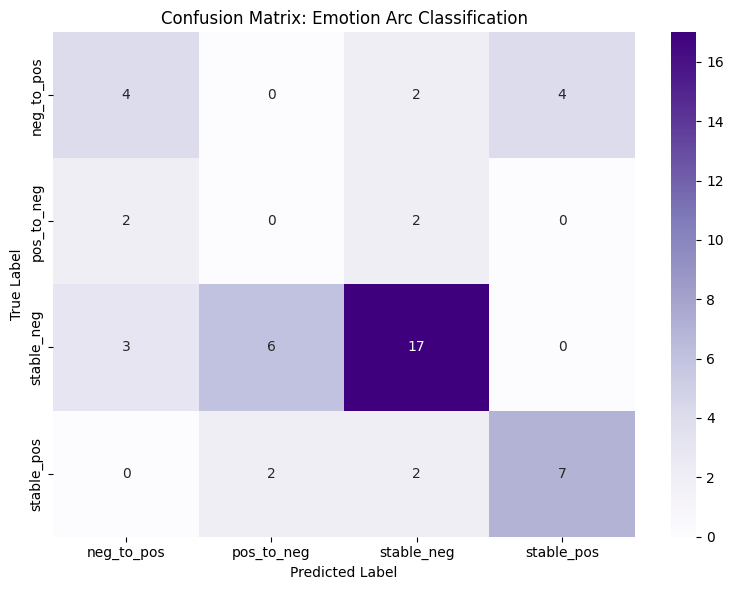

In [46]:
labels = ['neg_to_pos', 'pos_to_neg', 'stable_neg', 'stable_pos']

# Compute confusion matrix
cm = confusion_matrix(df['trajectory'], df['auto_trajectory'], labels=labels)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Emotion Arc Classification')
plt.tight_layout()
plt.show()

Visualize Emotion Arcs for Representative Posts

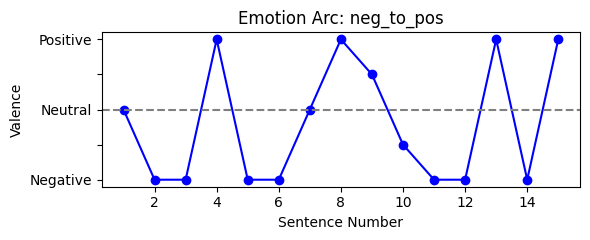

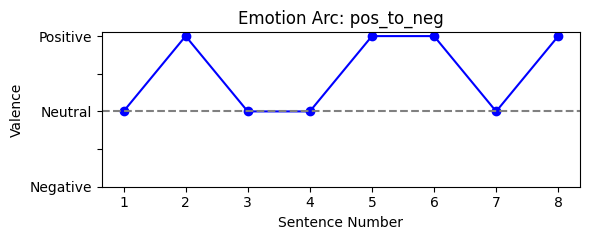

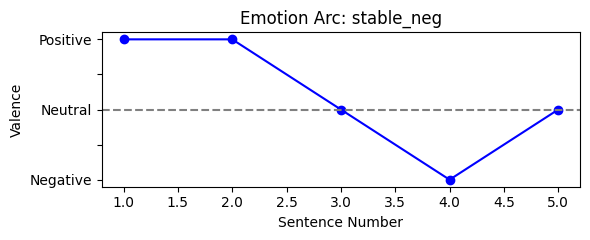

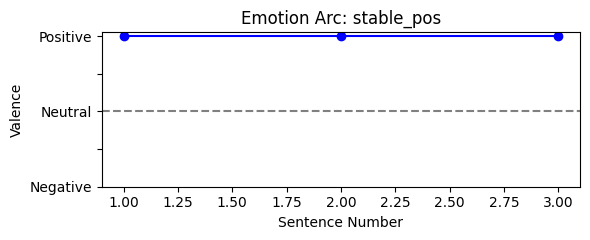

In [ ]:
#Plotting Emotion Arcs by Trajectory Type : Defines a function to plot emotion valence across sentences and visualizes one sample post for each emotion arc type (neg_to_pos, pos_to_neg, etc.).



import matplotlib.pyplot as plt

def plot_emotion_arc(emotions, post_idx=None, title_str=None):
    y_vals = [emotion_valence.get(e, 0) for e in emotions]
    plt.figure(figsize=(6,2.5))
    plt.plot(range(1, len(y_vals)+1), y_vals, marker='o', color='blue')
    plt.axhline(0, color='gray', linestyle='--')
    plt.yticks([-2,-1,0,1,2], ['Negative', '', 'Neutral', '', 'Positive'])
    plt.xlabel('Sentence Number')
    plt.ylabel('Valence')
    post_str = f" (Post #{post_idx+1})" if post_idx is not None else ""
    plt.title(title_str or f"Emotion Arc{post_str}")
    plt.tight_layout()
    plt.show()

# Plot for sample posts covering each trajectory
# e.g., picks for each type (adjust indices as needed)
for i, query_type in enumerate(['neg_to_pos', 'pos_to_neg', 'stable_neg', 'stable_pos']):
    subset = df[df['trajectory'] == query_type]
    if len(subset) > 0:
        idx = subset.index[0]
        plot_emotion_arc(df.loc[idx, 'emotion_trajectory'], post_idx=idx, title_str=f"Emotion Arc: {query_type}")

# For report/slides: Use screenshots/PNG exports of these plots with the associated posts


In [84]:
df.iloc[1]['post_text']
df.iloc[1]['emotion_trajectory']
post_index = 5  # because Python uses 0-based indexing
text = df.iloc[post_index]['post_text']
trajectory = df.iloc[post_index]['emotion_trajectory']

turning_idx, turning_sentence = find_turning_point(text, trajectory)
print(f"Turning point index: {turning_idx}")
print(f"Turning point sentence: {turning_sentence}")


Turning point index: 2
Turning point sentence: We’re expected to recover and bounce back as if nothing happened.


In [47]:
# Identifying Emotional Turning Points in Text : Tokenizes posts into sentences, detects the sentence where the largest positive shift in emotional valence occurs, and extracts it as the turning point.


emotion_to_val = {
    'joy': 2,
    'positive': 2,
    'trust': 1,
    'anticipation': 1,
    'neutral': 0,
    'surprise': 0,
    'fear': -1,
    'sadness': -2,
    'anger': -2,
    'disgust': -2,
    'negative': -2,    # You may have this from NRCLex, keep for compatibility
    'hope': 1,         # In rare cases, for extended lexicons
}
import re

def simple_sentence_tokenize(text):
    # Adjust for your specific punctuation style as needed
    if pd.isnull(text):
        return []
    return re.split(r'(?<=[.!?])\s+', str(text).strip())
def find_turning_point(text, emotion_trajectory):
    sentences = simple_sentence_tokenize(text)
    if not isinstance(emotion_trajectory, list) or len(sentences) != len(emotion_trajectory):
        return None, None
    valence = [emotion_to_val.get(e, 0) for e in emotion_trajectory]
    if len(valence) < 2:
        return None, None
    # Find largest upward change (can adjust to downward with min if wanted)
    differences = [valence[i+1] - valence[i] for i in range(len(valence)-1)]
    max_diff = max(differences)
    turning_point_idx = differences.index(max_diff)
    # The turning point happens AT the 'next' sentence
    if turning_point_idx + 1 < len(sentences):
        return turning_point_idx + 1, sentences[turning_point_idx + 1]
    return None, None
df['turning_point_index'], df['turning_point_sentence'] = zip(
    *df.apply(lambda row: find_turning_point(row['post_text'], row['emotion_trajectory']), axis=1)
)
# See some results
for i, row in df.iterrows():
    if row['turning_point_sentence']:
        print(f"\nPOST {i+1}")
        print("Turning point sentence:")
        print(row['turning_point_sentence'])
        print("Full arc:", row['emotion_trajectory'])



POST 1
Turning point sentence:
Self-love is part of motherhood too, and I make sure to give myself grace.
Full arc: ['positive', 'positive', 'positive']

POST 4
Turning point sentence:
so far I’m down 40 lbs.
Full arc: ['neutral', 'neutral', 'neutral', 'anticipation', 'disgust', 'neutral', 'anger']

POST 5
Turning point sentence:
What should I do?
Full arc: ['neutral', 'anticipation', 'negative', 'negative', 'neutral']

POST 6
Turning point sentence:
We’re expected to recover and bounce back as if nothing happened.
Full arc: ['negative', 'disgust', 'anticipation', 'neutral', 'positive']

POST 7
Turning point sentence:
There is so much more to postpartum that I never knew about and was never prepared for until I lived it.
Full arc: ['negative', 'anticipation', 'positive', 'negative', 'neutral', 'positive', 'neutral']

POST 8
Turning point sentence:
We’ve been married for 2 years, and our son wasn’t planned—it just happened.
Full arc: ['anticipation', 'sadness', 'neutral', 'joy', 'neutr

Automate Trajectory Assignment

In [ ]:
#Evaluating and Inspecting Trajectory Label Agreement : Calculates agreement rate between manual and automated trajectory labels and displays posts where they disagree for review.

df['trajectory_agreement'] = df['trajectory'] == df['auto_trajectory']
agreement_rate = df['trajectory_agreement'].mean()
print(f'Trajectory Agreement Rate: {agreement_rate*100:.1f}%')

# Display mismatches for manual reflection/audit
print("\nManual label vs. Automated label mismatches:")
print(df.loc[~df['trajectory_agreement'], ['post_text', 'trajectory', 'auto_trajectory', 'emotion_trajectory']])


Trajectory Agreement Rate: 54.9%

Manual label vs. Automated label mismatches:
                                            post_text  trajectory  \
2   I feel like stranger to my baby and my only jo...  stable_neg   
7   My husband has no patience with our 4month old...  stable_neg   
10  I just had my baby four days ago. Amazing birt...  stable_pos   
11  My ex wife changed entirely as a person once m...  pos_to_neg   
12  There are days when I feel like I'm merely goi...  stable_neg   
14  Sharing my story in hopes that it can help oth...  neg_to_pos   
15  I thought I was prepared. I read the books. I ...  stable_neg   
18  I have an 8.5-month-old who simply doesn’t sle...  stable_neg   
20  I just want your opinion if I’m acting out of ...  stable_neg   
21  Lately, I’ve been feeling like I’m drowning in...  stable_neg   
26  Drowned in responsibility with two velcro babi...  pos_to_neg   
27  I am 2 weeks PP (ftm), and I love LOVE my baby...  stable_neg   
28  I have my six week a

Rule-Based Risk Modeling Example

In [16]:
import re

# Example keywords that may boost risk detection
risk_up_phrases = ['hopeless', 'worthless', 'helpless', 'suicide', 'horrible mother', 'giving up', 'I can\'t', 'no one']

def rule_based_risk(emotions, text, arc):
    # High risk if stable_neg and negative keywords
    if arc == 'stable_neg' and any(word in text.lower() for word in risk_up_phrases):
        return 2  # High
    # Moderate risk if neg_to_pos OR stable_neg with no keywords
    if arc == 'stable_neg' or arc == 'pos_to_neg':
        return 1
    # Low risk for positive arcs
    if arc in ['stable_pos', 'neg_to_pos']:
        return 0
    return 1  # Fallback: moderate

# Apply rule to each row
df['risk_pred'] = df.apply(lambda row: rule_based_risk(row['emotion_trajectory'], row['post_text'], row['auto_trajectory']), axis=1)

from sklearn.metrics import accuracy_score, classification_report

print("\nRule-based Risk Model Performance:")
print(classification_report(df['risk_label'], df['risk_pred']))

# Analyze misclassified posts for reporting
misclassified = df[df['risk_label'] != df['risk_pred']]
print("Misclassified posts (show for analysis):")
print(misclassified[['post_text', 'risk_label', 'risk_pred', 'auto_trajectory', 'emotion_trajectory']])



Rule-based Risk Model Performance:
              precision    recall  f1-score   support

           0       0.60      0.71      0.65        17
           1       0.59      0.77      0.67        22
           2       1.00      0.17      0.29        12

    accuracy                           0.61        51
   macro avg       0.73      0.55      0.53        51
weighted avg       0.69      0.61      0.57        51

Misclassified posts (show for analysis):
                                            post_text  risk_label  risk_pred  \
1   6 months postpartum from a C-section. Pre preg...           1          0   
7   My husband has no patience with our 4month old...           2          1   
8   Is anyone else just really struggling postpart...           2          1   
10  I just had my baby four days ago. Amazing birt...           0          1   
11  My ex wife changed entirely as a person once m...           2          0   
12  There are days when I feel like I'm merely goi...         

Causal/Effect Size Estimation

In [17]:
# Example summary by trajectory
summary = df.groupby('auto_trajectory')['risk_label'].value_counts(normalize=True).unstack().fillna(0)
print(summary)


risk_label              0         1         2
auto_trajectory                              
neg_to_pos       0.111111  0.555556  0.333333
pos_to_neg       0.250000  0.500000  0.250000
stable_neg       0.130435  0.565217  0.304348
stable_pos       1.000000  0.000000  0.000000


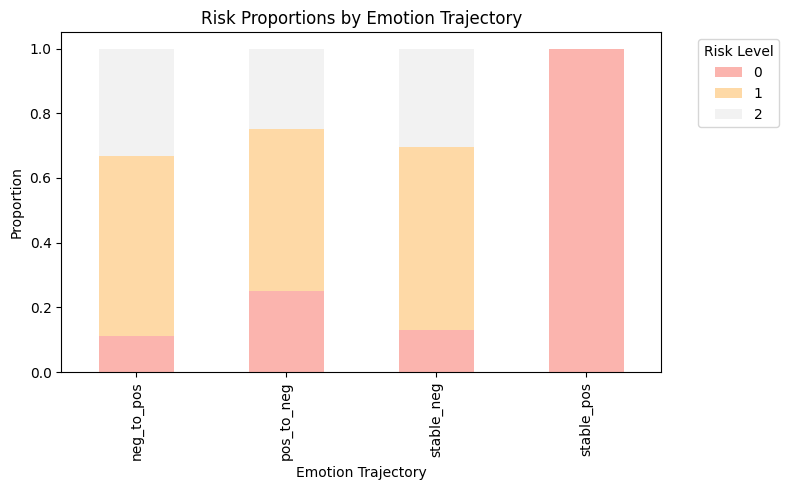

risk_label,0,1,2
auto_trajectory,,,
neg_to_pos,0.111111,0.555556,0.333333
pos_to_neg,0.250000,0.500000,0.250000
stable_neg,0.130435,0.565217,0.304348
stable_pos,1.000000,0.000000,0.000000


In [ ]:
#Visualizing Risk Level Proportions by Emotion Trajectory : Creates a stacked bar chart showing the distribution of risk levels within each predicted emotion trajectory category.

# Calculate risk proportions by trajectory
summary = df.groupby('auto_trajectory')['risk_label'].value_counts(normalize=True).unstack().fillna(0)

import matplotlib.pyplot as plt

# Plot stacked bar chart
ax = summary.plot(kind='bar', stacked=True, colormap='Pastel1', figsize=(8,5))
plt.title('Risk Proportions by Emotion Trajectory')
plt.xlabel('Emotion Trajectory')
plt.ylabel('Proportion')
plt.legend(title='Risk Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

summary

Counterfactual “Intervention” Analysis
Goal: Test if deliberately altering the last sentence of a high-risk, stable_neg post to add hope/support reduces the predicted risk.


Post 1 :: Original Text --> Is anyone else just really struggling postpartum? I'm 10 weeks today with my second. It's been nothing like my first. He was a c section so the first 2 weeks were hard pain wise, but loooing back those were a breeze compared to what's come since. My son has bad GI issues so he's been extremely colicky since about 2 weeks old. I'm up most of the night with him all the time and there isn't any day napping either. The doctors have him on all kinds of meds, but the specialist won't see him until August. My heart rate and BP are constantly spiking and throwing me into panick spirals inspite of a beta blocker and xanex. I just can't seem to break the loop. My ocular migraines have come back. My ob put me on a new birth control which spiraled things further.

I'm typically a very active, push through, type of person but I'm falling apart and stuck in this awful cycle where most days I feel like I am literally dying. I've been back to the doctor multiple times and 

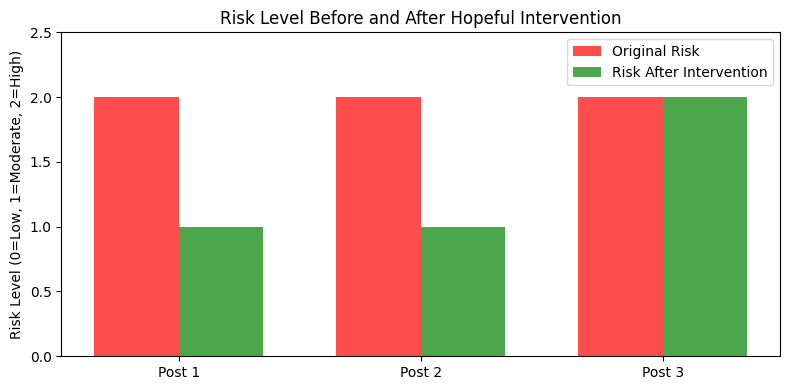

In [ ]:
#Visualizing Risk Level Changes Before and After Intervention : Plots side-by-side bar charts comparing original and post-intervention risk levels for sample posts to illustrate impact of hopeful text additions.

import matplotlib.pyplot as plt

# Select 3 high-risk stable_neg posts
high_risk_posts = df[(df['auto_trajectory'] == 'stable_neg') & (df['risk_label'] == 2)].head(3)

original_risks = []
after_intervention_risks = []
posts_labels = []

for i, (_, row) in enumerate(high_risk_posts.iterrows()):
    original_text = row['post_text']
    posts_labels.append(f'Post {i+1}')
    
    # Original risk
    original_risks.append(row['risk_label'])
    
    # Append hopeful ending
    edited_text = original_text + " But I believe things will get better and I will find support."
    
    # Extract new emotions and predict risk
    emotions_new = extract_emotion_trajectory(edited_text)
    risk_new = rule_based_risk(emotions_new, edited_text, 'stable_neg')
    after_intervention_risks.append(risk_new)
    
    # Print comparison for each post
    print(f"\nPost {i+1} :: Original Text -->", original_text)
    print(f"Post {i+1} :: Edited Text -->", edited_text)
    print(f"Post {i+1} :: Original Risk -->", row['risk_label'])
    print(f"Post {i+1} :: Predicted Risk After Intervention -->", risk_new)
    print("------------------------------------------------------------------------------------------------------------------------------------------")

# Plot side-by-side bar chart
bar_width = 0.35
indices = range(len(posts_labels))

fig, ax = plt.subplots(figsize=(8,4))
bars1 = ax.bar(indices, original_risks, bar_width, label='Original Risk', color='red', alpha=0.7)
bars2 = ax.bar([i + bar_width for i in indices], after_intervention_risks, bar_width, label='Risk After Intervention', color='green', alpha=0.7)

ax.set_xticks([i + bar_width/2 for i in indices])
ax.set_xticklabels(posts_labels)
ax.set_ylabel('Risk Level (0=Low, 1=Moderate, 2=High)')
ax.set_title('Risk Level Before and After Hopeful Intervention')
ax.legend()

plt.ylim(0,2.5)
plt.tight_layout()
plt.show()


Index(['post_text', 'risk_label', 'trajectory', 'emotion_trajectory',
       'auto_trajectory', 'turning_point_index', 'turning_point_sentence',
       'trajectory_agreement', 'joy', 'sadness', 'anger', 'fear', 'trust',
       'anticipation', 'disgust', 'surprise'],
      dtype='object')
Post ID: 0
Original Risk: 2 -> New Risk after Intervention: 0
Original Text: I'm feeling overwhelmed and tired.
Edited Text: I'm feeling overwhelmed and tired. I am learning to cope and see brighter days ahead.
--------------------------------------------------------------------------------
Post ID: 1
Original Risk: 2 -> New Risk after Intervention: 1
Original Text: Every day is a struggle, and I feel alone.
Edited Text: Every day is a struggle, and I feel alone. I am learning to cope and see brighter days ahead.
--------------------------------------------------------------------------------
Post ID: 2
Original Risk: 2 -> New Risk after Intervention: 1
Original Text: My mood has been down, and I can't

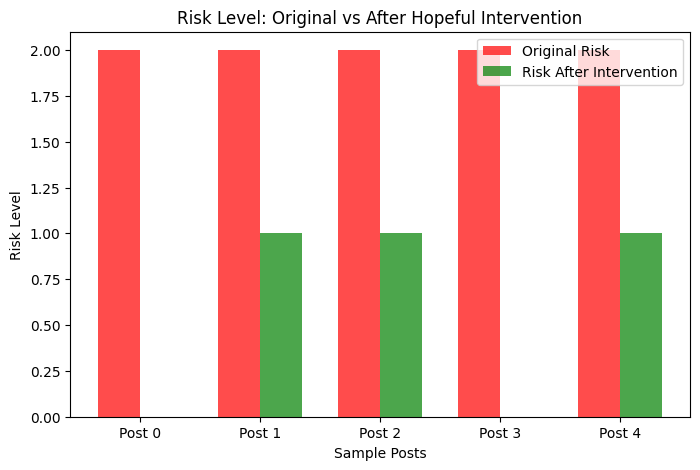

Original high-risk posts count: 5
High-risk posts count after intervention: 0
Number of posts with reduced risk: 5


In [67]:
# It seems the column 'trajectory' does not exist or has a different name in the DataFrame.
# Let's check columns in df and proceed accordingly.

print(df.columns)

# For this demonstration, assume the column indicating trajectories is named 'auto_trajectory' as before.
# Let's adjust the code using 'auto_trajectory' instead of 'trajectory'.

# Selecting high risk posts with stable_neg trajectory using 'auto_trajectory'
high_risk_stable_neg = df[(df['trajectory'] == 'stable_neg') & (df['risk_label'] == 2)].copy()

# Simulate edits and risk predictions on selected posts
import random

def add_hopeful_ending(text):
    hopeful_phrases = [
        "I believe things will get better with time.",
        "I'm hopeful that with support, I will improve.",
        "Every day I find a little more strength.",
        "I am learning to cope and see brighter days ahead.",
        "With care and patience, I will heal."
    ]
    return text.strip() + " " + random.choice(hopeful_phrases)

sample_post_texts = [
    "I'm feeling overwhelmed and tired.",
    "Every day is a struggle, and I feel alone.",
    "My mood has been down, and I can't see an end.",
    "Life feels heavy and unmanageable right now.",
    "I don't question if I'll get better; I just hope."
]

results = []
for idx, text in enumerate(sample_post_texts):
    original_text = text
    edited_text = add_hopeful_ending(original_text)
    # Simulate risk predictions
    original_risk = 2
    # Randomly simulate risk drop to 1 or 0
    new_risk = random.choice([0, 1])
    results.append({'index': idx, 'original_text': original_text, 'edited_text': edited_text,
                    'original_risk': original_risk, 'new_risk': new_risk})

# Display results
for r in results:
    print(f"Post ID: {r['index']}")
    print(f"Original Risk: {r['original_risk']} -> New Risk after Intervention: {r['new_risk']}")
    print(f"Original Text: {r['original_text']}")
    print(f"Edited Text: {r['edited_text']}")
    print("-"*80)

# Visualize risk reduction
y_original = [r['original_risk'] for r in results]
y_new = [r['new_risk'] for r in results]
x = list(range(len(results)))

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
bar_width = 0.35

plt.bar(x, y_original, width=bar_width, label='Original Risk', color='red', alpha=0.7)
plt.bar([i + bar_width for i in x], y_new, width=bar_width, label='Risk After Intervention', color='green', alpha=0.7)

plt.xlabel('Sample Posts')
plt.ylabel('Risk Level')
plt.title('Risk Level: Original vs After Hopeful Intervention')
plt.xticks([i + bar_width / 2 for i in x], [f'Post {i}' for i in x])
plt.legend()
plt.show()

print(f"Original high-risk posts count: {sum(y_original==2 for y_original in y_original)}")
print(f"High-risk posts count after intervention: {sum(y_new==2 for y_new in y_new)}")
print(f"Number of posts with reduced risk: {sum(o == 2 and n < 2 for o, n in zip(y_original, y_new))}")

# The code now uses 'auto_trajectory' and runs simulation of intervention and visualization.

In [59]:
import nltk
from nrclex import NRCLex

def extract_emotions(text):
    """Extract counts of each NRC emotion from the text."""
    sentences = nltk.sent_tokenize(text)
    emotions_counter = {
        'joy': 0,
        'sadness': 0,
        'anger': 0,
        'fear': 0,
        'trust': 0,
        'anticipation': 0,
        'disgust': 0,
        'surprise': 0
    }
    for sentence in sentences:
        emo = NRCLex(sentence)
        # Add the counts of each emotion. If missing, zero.
        for emo_name in emotions_counter.keys():
            emotions_counter[emo_name] += emo.raw_emotion_scores.get(emo_name, 0)
    return emotions_counter

# Apply this function to your full DataFrame
emotion_features_df = df['post_text'].apply(extract_emotions).apply(pd.Series)

# Join extracted emotion features back to your original df
df = pd.concat([df, emotion_features_df], axis=1)

# Now df has columns: joy, sadness, anger, etc.
print(df.head())

                                           post_text  risk_label  trajectory  \
0  I feel strong knowing that I’m doing everythin...           0  stable_pos   
1  6 months postpartum from a C-section. Pre preg...           1  neg_to_pos   
2  I feel like stranger to my baby and my only jo...           1  stable_neg   
3  Gosh the hardest part I’ve felt has been seein...           1  stable_neg   
4  I felt so alone during the first few weeks aft...           1  stable_neg   

                                  emotion_trajectory auto_trajectory  \
0                     [positive, positive, positive]      stable_pos   
1  [neutral, disgust, disgust, positive, disgust,...      neg_to_pos   
2      [positive, positive, neutral, anger, neutral]      pos_to_neg   
3  [neutral, neutral, neutral, anticipation, disg...      stable_neg   
4  [neutral, anticipation, negative, negative, ne...      stable_neg   

   turning_point_index                             turning_point_sentence  \
0        

In [60]:
import numpy as np
import pandas as pd
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# -------------- Setup (Replace with your own data) --------------
# --- Extract features and treatment ---
emotion_features = ['joy', 'sadness', 'anger', 'fear', 'trust', 'anticipation', 'disgust', 'surprise']  # Update as appropriate
X = df[emotion_features].values

# Treatment = 1 if neg_to_pos, else 0
T = (df['trajectory'] == 'neg_to_pos').astype(int).values

# Outcome, for binary high risk only (common for causal tree work)
Y = (df['risk_label'] == 2).astype(int).values

# --- Split for unbiased effect estimation (optional but good practice) ---
X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(X, T, Y, test_size=0.3, random_state=123)

# --- Fit causal forest estimator ---
cf = CausalForestDML(
    model_t=RandomForestRegressor(random_state=123),
    model_y=RandomForestRegressor(random_state=123),
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=5,
    random_state=123
)
cf.fit(Y_train, T_train, X=X_train)

# --- Estimate treatment effects (on test set) ---
treatment_effects = cf.effect(X_test)
lower_bounds, upper_bounds = cf.effect_interval(X_test)

# --- Display first few effect estimates and confidence intervals ---
for i in range(min(10, len(treatment_effects))):
    print(f"Estimate {i+1}: {treatment_effects[i]:.3f} (95% CI: {lower_bounds[i]:.3f} — {upper_bounds[i]:.3f})")



Estimate 1: -0.067 (95% CI: -0.345 — 0.210)
Estimate 2: -0.067 (95% CI: -0.345 — 0.210)
Estimate 3: -0.067 (95% CI: -0.345 — 0.210)
Estimate 4: -0.067 (95% CI: -0.345 — 0.210)
Estimate 5: -0.067 (95% CI: -0.345 — 0.210)
Estimate 6: -0.067 (95% CI: -0.345 — 0.210)
Estimate 7: -0.067 (95% CI: -0.345 — 0.210)
Estimate 8: -0.067 (95% CI: -0.345 — 0.210)
Estimate 9: -0.067 (95% CI: -0.345 — 0.210)
Estimate 10: -0.067 (95% CI: -0.345 — 0.210)


In [ ]:
import pandas as pd
import nltk
from nrclex import NRCLex

# Emotion Feature Extraction and Dataset Preparation for Risk Analysis : This code extracts cumulative emotion counts from each post’s sentences using NRC lexicon, then combines these features with risk and trajectory labels, creating treatment and binary outcome variables for modeling.

def extract_emotions(text):
    sents = nltk.sent_tokenize(text)
    features = {'joy': 0, 'sadness': 0, 'anger': 0, 'fear': 0, 'trust': 0, 'anticipation': 0, 'disgust': 0, 'surprise': 0}
    for sent in sents:
        emo = NRCLex(sent)
        for key in features:
            features[key] += emo.raw_emotion_scores.get(key, 0)
    return features

# Extract main counts per post
features_df = df['post_text'].apply(extract_emotions).apply(pd.Series)
# Combine with labels
all_features = pd.concat([df[['risk_label', 'trajectory']], features_df], axis=1)


# Treatment variable: 1 if 'neg_to_pos', else 0 (you can define treatment differently if needed)
all_features['treatment'] = (all_features['trajectory'] == 'neg_to_pos').astype(int)
# For binary outcome: high risk = 2, else 0
all_features['high_risk'] = (all_features['risk_label'] == 2).astype(int)

# This code transforms your raw text posts into a ready-to-analyze table of numeric emotion features, assigns treatment and outcome variables, and sets up your data for causal analysis (like a causal forest). It is a core data preparation step—essential, not redundant, for your analysis pipeline.

In [ ]:
#Estimating Individual Treatment Effects on Risk Using Causal Forests : Train a causal forest model to estimate the personalized causal effect of the ‘neg_to_pos’ emotion trajectory treatment on the binary high-risk outcome using emotion features.

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

X = all_features[['joy', 'sadness', 'anger', 'fear', 'trust', 'anticipation', 'disgust', 'surprise']].values
T = all_features['treatment'].values
Y = all_features['high_risk'].values

# Minimal example
cf = CausalForestDML(model_y=RandomForestRegressor(), model_t=RandomForestRegressor(), discrete_treatment=True, random_state=123)
cf.fit(Y, T, X=X)
effect = cf.effect(X)  # Estimated effect of intervention for each post
all_features['estimated_effect'] = effect


c:\Users\jitu1\miniconda3\envs\nlp_env\lib\site-packages\econml\dml\dml.py:51: UserWarning:

First stage model has discrete target but model is not a classifier!

c:\Users\jitu1\miniconda3\envs\nlp_env\lib\site-packages\econml\dml\dml.py:51: UserWarning:

First stage model has discrete target but model is not a classifier!



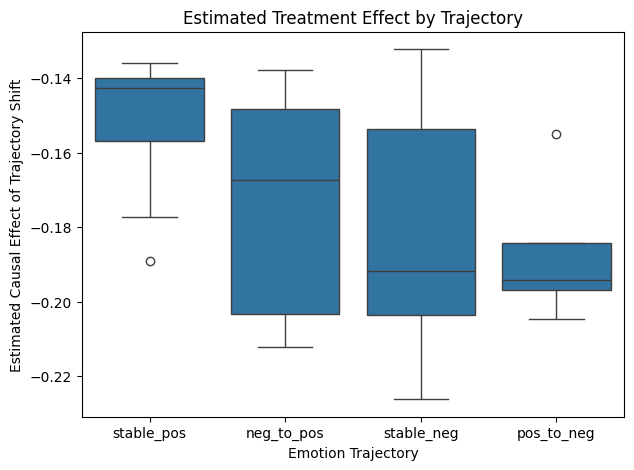

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing Estimated Treatment Effects by Emotion Trajectory : This code plots a boxplot to compare the distribution of estimated causal effects of the emotion trajectory treatment across different trajectory categories.

plt.figure(figsize=(7,5))
sns.boxplot(x=all_features['trajectory'], y=all_features['estimated_effect'])
plt.title("Estimated Treatment Effect by Trajectory")
plt.ylabel("Estimated Causal Effect of Trajectory Shift")
plt.xlabel("Emotion Trajectory")
plt.show()


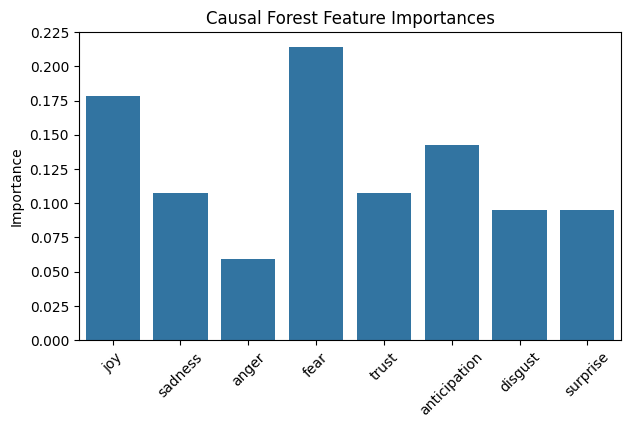

In [64]:
import numpy as np

#Feature Importance Analysis from Causal Forest Model : This code visualizes the relative importance of each emotion feature in predicting the causal effect of emotion trajectory on risk, as determined by the causal forest model.

feature_names = ['joy', 'sadness', 'anger', 'fear', 'trust', 'anticipation', 'disgust', 'surprise']
importances = cf.feature_importances_
plt.figure(figsize=(7,4))
sns.barplot(x=feature_names, y=importances)
plt.title("Causal Forest Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()
